<a href="https://colab.research.google.com/github/jayden14141/Network-Anomaly-Detection/blob/main/ml/notebooks/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

USE_DRIVE = True

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    data = pd.read_csv('/content/drive/MyDrive/cicids2017_combined.csv')
    print(f"Loaded from Drive: {data.shape}")
except:
    from google.colab import files
    uploaded = files.upload()
    data = pd.read_csv('cicids2017_combined.csv')
    print(f"Loaded from upload: {data.shape}")

Mounted at /content/drive
Loaded from Drive: (2830743, 79)


In [2]:
# Strip whitespace from column names
data.columns = data.columns.str.strip()

# Replace infinity with NaN
data.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop NaN rows
before = len(data)
data.dropna(inplace=True)
print(f"Rows removed: {before - len(data):,}")
print(f"Remaining: {data.shape}")

Rows removed: 2,867
Remaining: (2827876, 79)


In [3]:
# Fix Web Attack label encoding (the � character from original CSV)
data['Label'] = data['Label'].str.replace('�', '-', regex=False).str.strip()
print(data['Label'].value_counts())

Label
BENIGN                        2271320
DoS Hulk                       230124
PortScan                       158804
DDoS                           128025
DoS GoldenEye                   10293
FTP-Patator                      7935
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1956
Web Attack - Brute Force         1507
Web Attack - XSS                  652
Infiltration                       36
Web Attack - Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [4]:
attack_counts = data['Label'].value_counts().drop('BENIGN')

large_attacks = attack_counts[attack_counts >= 10000].index.tolist()
medium_attacks = attack_counts[(attack_counts >= 1000) & (attack_counts < 10000)].index.tolist()
small_attacks = attack_counts[attack_counts < 1000].index.tolist()

print(f"Large attacks (10k+):    {len(large_attacks)} types")
for a in large_attacks:
    print(f"  {a:<35} {attack_counts[a]:>10,}")

print(f"\nMedium attacks (1k-10k): {len(medium_attacks)} types")
for a in medium_attacks:
    print(f"  {a:<35} {attack_counts[a]:>10,}")

print(f"\nSmall attacks (<1k):     {len(small_attacks)} types")
for a in small_attacks:
    print(f"  {a:<35} {attack_counts[a]:>10,}")

Large attacks (10k+):    4 types
  DoS Hulk                               230,124
  PortScan                               158,804
  DDoS                                   128,025
  DoS GoldenEye                           10,293

Medium attacks (1k-10k): 6 types
  FTP-Patator                              7,935
  SSH-Patator                              5,897
  DoS slowloris                            5,796
  DoS Slowhttptest                         5,499
  Bot                                      1,956
  Web Attack - Brute Force                 1,507

Small attacks (<1k):     4 types
  Web Attack - XSS                           652
  Infiltration                                36
  Web Attack - Sql Injection                  21
  Heartbleed                                  11


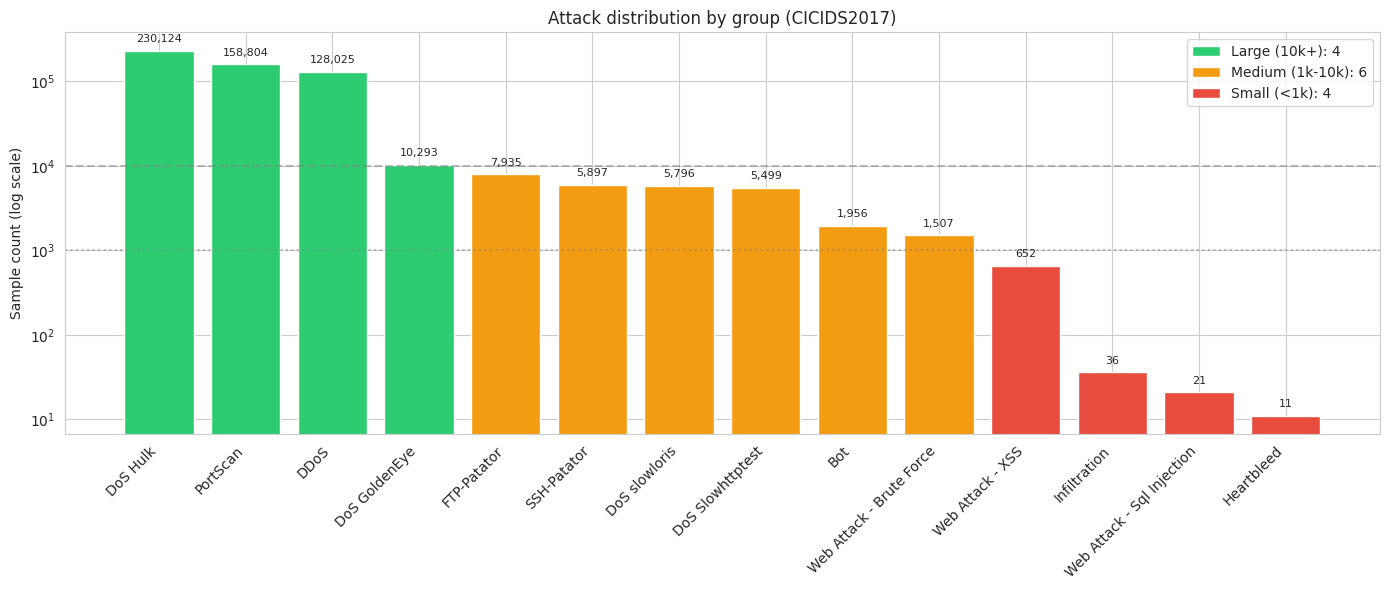

In [5]:
# Visualize attack distribution by group (log scale)
fig, ax = plt.subplots(figsize=(14, 6))

colors = []
for label in attack_counts.index:
    if label in large_attacks:
        colors.append('#2ecc71')   # green = large
    elif label in medium_attacks:
        colors.append('#f39c12')   # orange = medium
    else:
        colors.append('#e74c3c')   # red = small

bars = ax.bar(range(len(attack_counts)), attack_counts.values, color=colors)
ax.set_yscale('log')
ax.set_xticks(range(len(attack_counts)))
ax.set_xticklabels(attack_counts.index, rotation=45, ha='right')
ax.set_ylabel('Sample count (log scale)')
ax.set_title('Attack distribution by group (CICIDS2017)')

ax.axhline(10000, color='gray', linestyle='--', alpha=0.5, label='Large threshold (10k)')
ax.axhline(1000, color='gray', linestyle=':', alpha=0.5, label='Medium threshold (1k)')

for bar, count in zip(bars, attack_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, count*1.2,
            f'{count:,}', ha='center', va='bottom', fontsize=8)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label=f'Large (10k+): {len(large_attacks)}'),
    Patch(facecolor='#f39c12', label=f'Medium (1k-10k): {len(medium_attacks)}'),
    Patch(facecolor='#e74c3c', label=f'Small (<1k): {len(small_attacks)}'),
]
ax.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.show()

In [6]:
n_benign = (data['Label'] == 'BENIGN').sum()

imbalance = pd.DataFrame({
    'attack': attack_counts.index,
    'attack_count': attack_counts.values,
    'benign_count': n_benign,
    'ratio_benign_to_attack': (n_benign / attack_counts.values).round(1),
    'group': ['Large' if a in large_attacks else 'Medium' if a in medium_attacks else 'Small'
              for a in attack_counts.index]
})

print(imbalance.to_string(index=False))

                    attack  attack_count  benign_count  ratio_benign_to_attack  group
                  DoS Hulk        230124       2271320                     9.9  Large
                  PortScan        158804       2271320                    14.3  Large
                      DDoS        128025       2271320                    17.7  Large
             DoS GoldenEye         10293       2271320                   220.7  Large
               FTP-Patator          7935       2271320                   286.2 Medium
               SSH-Patator          5897       2271320                   385.2 Medium
             DoS slowloris          5796       2271320                   391.9 Medium
          DoS Slowhttptest          5499       2271320                   413.0 Medium
                       Bot          1956       2271320                  1161.2 Medium
  Web Attack - Brute Force          1507       2271320                  1507.2 Medium
          Web Attack - XSS           652       2271320

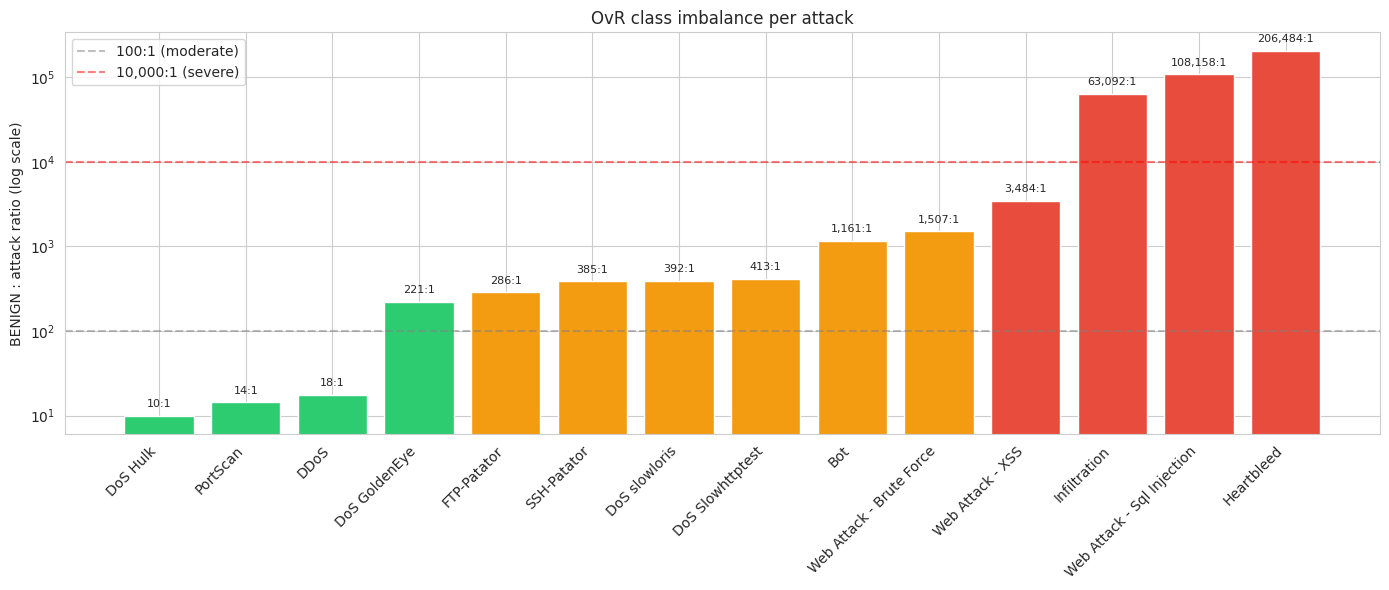

In [7]:
# Visualize imbalance ratio (log scale)
fig, ax = plt.subplots(figsize=(14, 6))
group_color = {'Large': '#2ecc71', 'Medium': '#f39c12', 'Small': '#e74c3c'}
bar_colors = [group_color[g] for g in imbalance['group']]

bars = ax.bar(imbalance['attack'], imbalance['ratio_benign_to_attack'], color=bar_colors)
ax.set_yscale('log')
ax.set_ylabel('BENIGN : attack ratio (log scale)')
ax.set_title('OvR class imbalance per attack')
ax.set_xticklabels(imbalance['attack'], rotation=45, ha='right')

for bar, ratio in zip(bars, imbalance['ratio_benign_to_attack']):
    ax.text(bar.get_x() + bar.get_width()/2, ratio*1.2,
            f'{ratio:,.0f}:1', ha='center', va='bottom', fontsize=8)

ax.axhline(100, color='gray', linestyle='--', alpha=0.5, label='100:1 (moderate)')
ax.axhline(10000, color='red', linestyle='--', alpha=0.5, label='10,000:1 (severe)')
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
import json

attack_groups = {
    'large': large_attacks,
    'medium': medium_attacks,
    'small': small_attacks,
}

data.to_csv('/content/drive/MyDrive/cicids2017_cleaned.csv', index=False)
with open('/content/drive/MyDrive/attack_groups.json', 'w') as f:
    json.dump(attack_groups, f, indent=2)

print('Saved:')
print('  cicids2017_cleaned.csv')
print('  attack_groups.json')

Saved:
  cicids2017_cleaned.csv
  attack_groups.json
